# ERCS Experiment Report
## Emergency Response Coordination Simulator
### Adaptive vs Baseline Coordination Under Intermittent Connectivity

MSc Computer Science — University of Liverpool, 2026

This notebook runs the complete ERCS experiment and produces publication-quality
visualizations and statistical analysis for the dissertation.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure src is on the path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from ercs.config.parameters import AlgorithmType, SimulationConfig
from ercs.evaluation.metrics import MetricType, PerformanceEvaluator
from ercs.simulation.engine import ExperimentRunner
from ercs.visualization.plots import (
    METRICS_CONFIG,
    apply_thesis_style,
    build_anova_table,
    build_parameter_tables,
    build_results_dataframe,
    build_ttest_table,
    compute_summary_stats,
    plot_box_distributions,
    plot_degradation_lines,
    plot_grouped_bars,
    plot_heatmap,
    save_figure,
)

apply_thesis_style()
FIGURES_DIR = project_root / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Experiment Parameters

All parameters are sourced from published literature and configured
in `configs/default.yaml`.

In [2]:
config = SimulationConfig()

tables = build_parameter_tables(config)
for name, table_df in tables.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    display(table_df.style.hide(axis="index"))


  Network Topology


Parameter,Value,Source
Node count,50 (2 coordination + 48 mobile),Ullah & Qayyum (2022)
Simulation area,3000 x 1500 m²,Ullah & Qayyum (2022)
Incident zone,700 x 600 m²,Ullah & Qayyum (2022)
Radio range,100 m,Ullah & Qayyum (2022)
Buffer size,25 MB,Ullah & Qayyum (2022)
Message size,512 kB,Kumar et al. (2023)
Connectivity scenarios,"75%, 40%, 20%",Karaman et al. (2026)
Mobility model,Random Waypoint,Ullah & Qayyum (2022)
Speed range,0–20 m/s,Ullah & Qayyum (2022)



  PRoPHET Protocol


Parameter,Value,Source
P_enc_max,0.5,Grasic et al. (2011)
I_typ,1800 s,Grasic et al. (2011)
β (transitivity),0.9,Grasic et al. (2011)
γ (aging),0.999885791,Grasic et al. (2011)
Message TTL,300 min,Ullah & Qayyum (2022)
Transmit speed,2 Mbps,Ullah & Qayyum (2022)
Buffer drop policy,Drop Oldest,Ullah & Qayyum (2022)



  Scenario Generation


Parameter,Value,Source
Task arrival,Poisson,Pu et al. (2025)
Message rate,2.0 msgs/min,Kumar et al. (2023)
Urgency distribution,20% H / 50% M / 30% L,Li et al. (2025)
Simulation duration,6000 s (100 min),Ullah & Qayyum (2022)
Runs per configuration,30,Law (2015)



  Coordination


Parameter,Value,Source
Update interval,30 min,Kaji et al. (2025)
Priority levels,3,Rosas et al. (2023)
Path threshold,P > 0.3,Ullah & Qayyum (2022)
Adaptive ordering,Urgency First,Kaji et al. (2025)
Baseline ordering,FCFS,Design decision


In [3]:
connectivity_levels = config.network.connectivity_scenarios
runs_per_config = config.scenario.runs_per_configuration

print("Experimental Design")
print("=" * 40)
print(f"  Algorithms:          2 (Adaptive, Baseline)")
print(f"  Connectivity levels: {len(connectivity_levels)} ({', '.join(f'{c*100:.0f}%' for c in connectivity_levels)})")
print(f"  Runs per config:     {runs_per_config}")
print(f"  Total runs:          {config.total_experimental_runs}")
print(f"  Sim duration:        {config.scenario.simulation_duration_seconds}s ({config.scenario.simulation_duration_seconds // 60} min)")

Experimental Design
  Algorithms:          2 (Adaptive, Baseline)
  Connectivity levels: 3 (75%, 40%, 20%)
  Runs per config:     30
  Total runs:          180
  Sim duration:        6000s (100 min)


## 2. Experiment Execution

Running all 180 simulations (2 algorithms x 3 connectivity levels x 30 runs).

> To run a quick test, change `runs_per_config` below to `5`.

In [4]:
from IPython.display import clear_output

# Change to 5 for a quick test
RUNS = runs_per_config



runner = ExperimentRunner(config=config, base_seed=42)
algorithms = [AlgorithmType.ADAPTIVE, AlgorithmType.BASELINE]
total = len(algorithms) * len(connectivity_levels) * RUNS
start_time = time.time()


def progress_callback(current, total_runs):
    clear_output(wait=True)
    pct = current / total_runs * 100
    bar_len = 40
    filled = int(bar_len * current // total_runs)
    bar = "=" * filled + ">" + " " * max(0, bar_len - filled - 1)
    elapsed = time.time() - start_time
    eta = (elapsed / current) * (total_runs - current) if current > 0 else 0

    alg_idx = (current - 1) // (len(connectivity_levels) * RUNS)
    remainder = (current - 1) % (len(connectivity_levels) * RUNS)
    conn_idx = remainder // RUNS
    run_idx = remainder % RUNS

    alg_name = algorithms[alg_idx].value.capitalize()
    conn_pct = f"{connectivity_levels[conn_idx] * 100:.0f}%"

    print(f"ERCS Experiment Progress")
    print(f"[{bar}] {current}/{total_runs} ({pct:.1f}%)")
    print(f"Current: {alg_name} @ {conn_pct} connectivity, run {run_idx + 1}/{RUNS}")
    print(f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")


results = runner.run_all(
    algorithms=algorithms,
    connectivity_levels=connectivity_levels,
    runs_per_config=RUNS,
    progress_callback=progress_callback,
)

clear_output(wait=True)
elapsed_total = time.time() - start_time
print(f"Experiment complete: {len(results)} runs in {elapsed_total:.1f}s")
print(f"Average time per run: {elapsed_total / len(results):.2f}s")

Experiment complete: 180 runs in 2305.5s
Average time per run: 12.81s


In [5]:
df = build_results_dataframe(results)
print(f"Results DataFrame: {df.shape[0]} rows x {df.shape[1]} columns\n")
display(
    df.groupby(["algorithm", "connectivity"])[["delivery_rate", "assignment_rate", "avg_response_time"]]
    .describe()
    .round(4)
)

Results DataFrame: 180 rows x 12 columns



delivery_rate                                          \
                               count    mean     std     min     25%     50%   
algorithm connectivity                                                         
adaptive  0.20                  30.0  0.8838  0.2001  0.0000  0.9139  0.9469   
          0.40                  30.0  0.9769  0.0239  0.9023  0.9727  0.9848   
          0.75                  30.0  0.9678  0.0260  0.9100  0.9502  0.9766   
baseline  0.20                  30.0  0.8967  0.1458  0.4355  0.9013  0.9477   
          0.40                  30.0  0.9863  0.0318  0.8372  0.9908  0.9975   
          0.75                  30.0  0.9705  0.0387  0.8372  0.9584  0.9832   

                                    assignment_rate          ...          \
                           75%  max           count    mean  ...     75%   
algorithm connectivity                                       ...           
adaptive  0.20          0.9776  1.0            30.0  0.8602  ...  0.9064   
          0.40          0.9893  1.0            30.0  0.8910  ...  0.9090   
          0.75          0.9886  1.0            30.0  0.8910  ...  0.9090   
baseline  0.20          0.9796  1.0            30.0  0.8910  ...  0.9090   
          0.40          1.0000  1.0            30.0  0.8910  ...  0.9090   
          0.75          1.0000  1.0            30.0  0.8910  ...  0.9090   

                               avg_response_time                               \
                           max             count      mean      std       min   
algorithm connectivity                                                          
adaptive  0.20          0.9267              29.0  888.0405  32.1531  795.0636   
          0.40          0.9267              30.0  889.7913  33.0171  795.0636   
          0.75          0.9267              30.0  889.7913  33.0171  795.0636   
baseline  0.20          0.9267              30.0  889.7913  33.0171  795.0636   
          0.40          0.9267              30.0  889.7913  33.0171  795.0636   
          0.75          0.9267              30.0  889.7913  33.0171  795.0636   

                                                                
                             25%       50%       75%       max  
algorithm connectivity                                          
adaptive  0.20          872.4268  890.9171  906.0714  943.4394  
          0.40          874.5982  895.6276  906.2872  943.4394  
          0.75          874.5982  895.6276  906.2872  943.4394  
baseline  0.20          874.5982  895.6276  906.2872  943.4394  
          0.40          874.5982  895.6276  906.2872  943.4394  
          0.75          874.5982  895.6276  906.2872  943.4394  

[6 rows x 24 columns]

## 3. Results Visualization

All figures use a consistent colour scheme:
- **Adaptive** (blue): Network-aware, urgency-first coordination
- **Baseline** (red): Proximity-only, FCFS coordination

In [6]:
# Precompute summary statistics for all metrics
summaries = {}
for metric_key in METRICS_CONFIG:
    summaries[metric_key] = compute_summary_stats(df, metric_key)

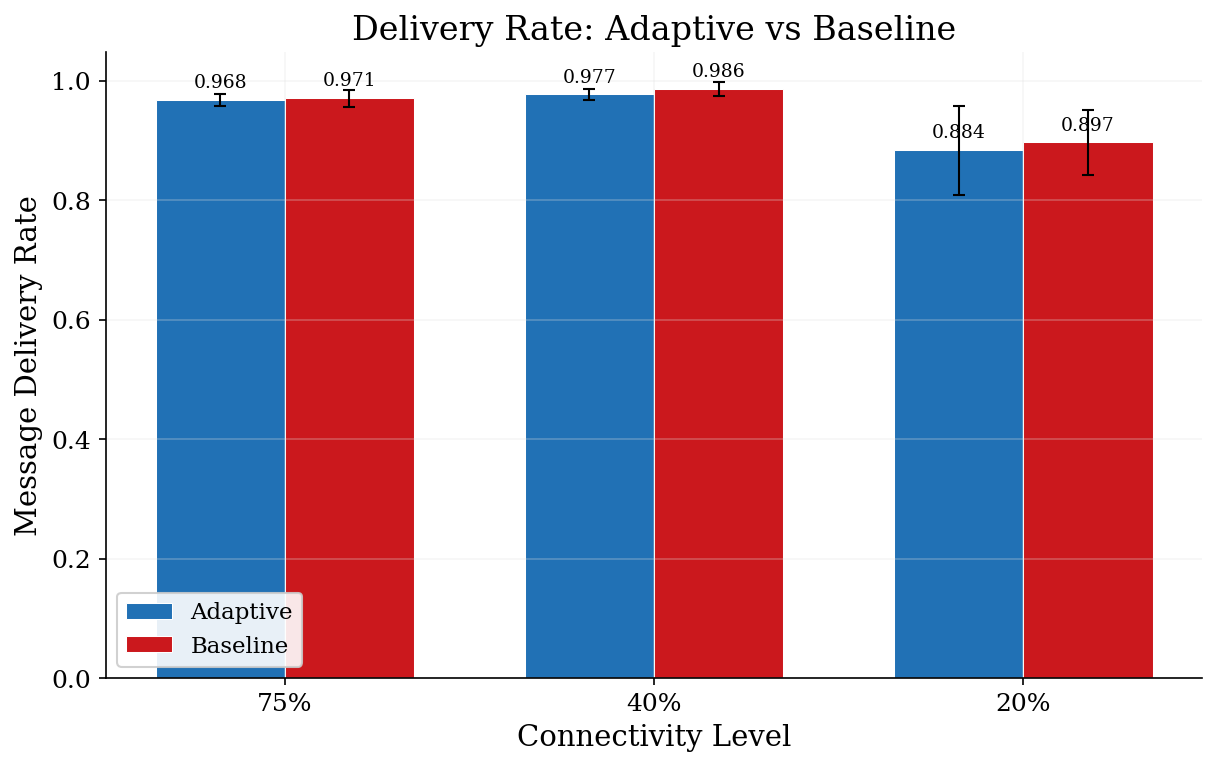

In [7]:
# Figure 1: Delivery Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["delivery_rate"], "delivery_rate")
save_figure(fig, "fig_delivery_rate_bars", FIGURES_DIR)
plt.show()

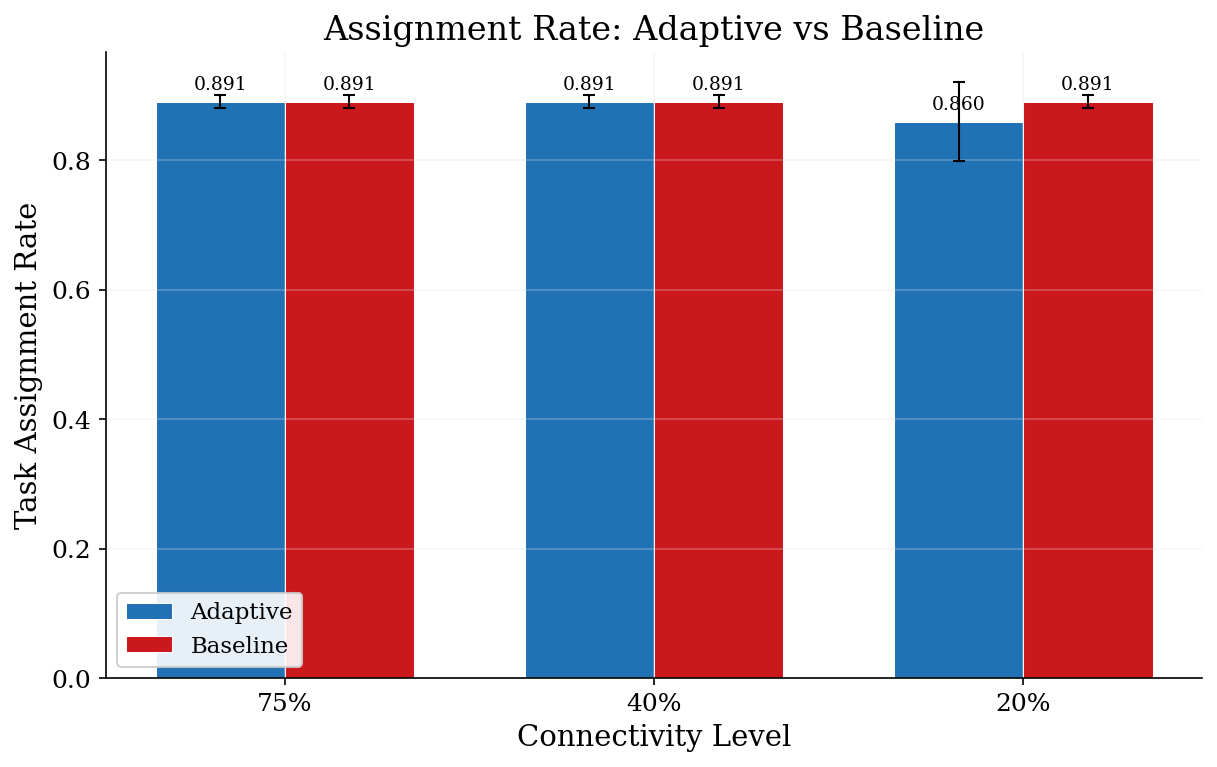

In [8]:
# Figure 2: Assignment Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["assignment_rate"], "assignment_rate")
save_figure(fig, "fig_assignment_rate_bars", FIGURES_DIR)
plt.show()

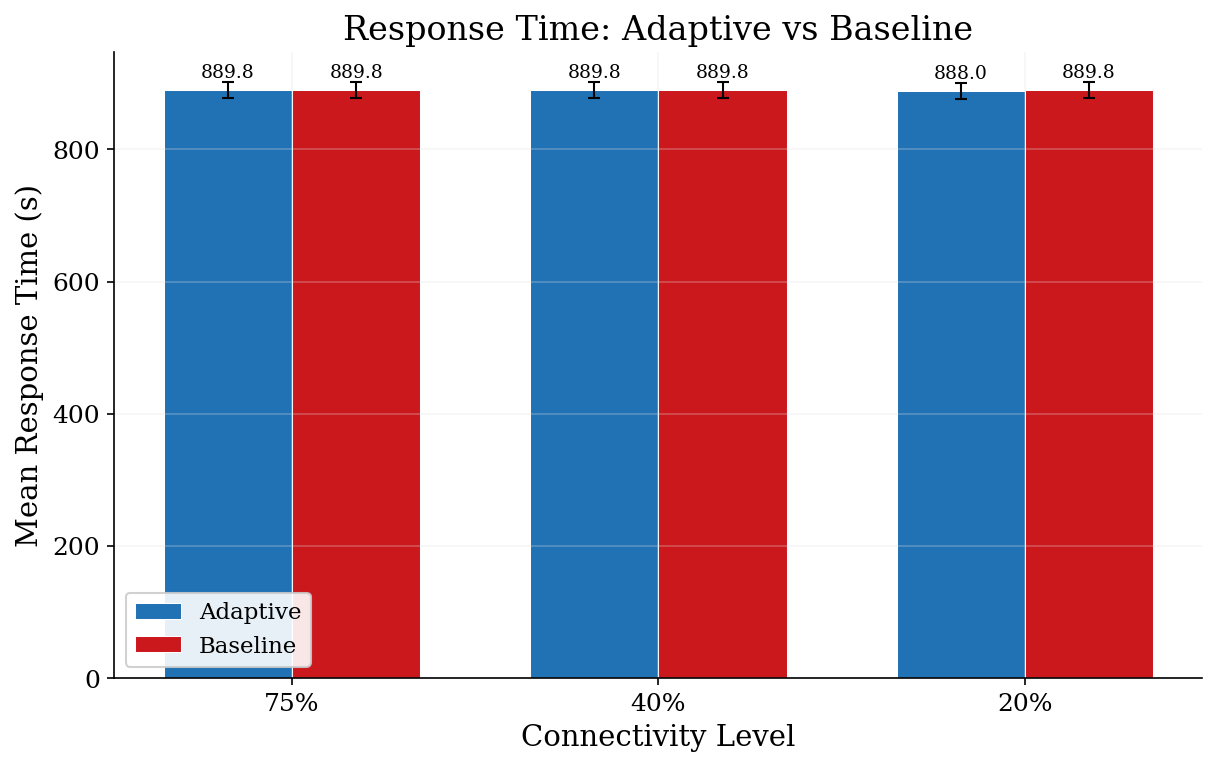

In [9]:
# Figure 3: Response Time — Grouped Bar Chart
fig = plot_grouped_bars(summaries["avg_response_time"], "avg_response_time")
save_figure(fig, "fig_response_time_bars", FIGURES_DIR)
plt.show()

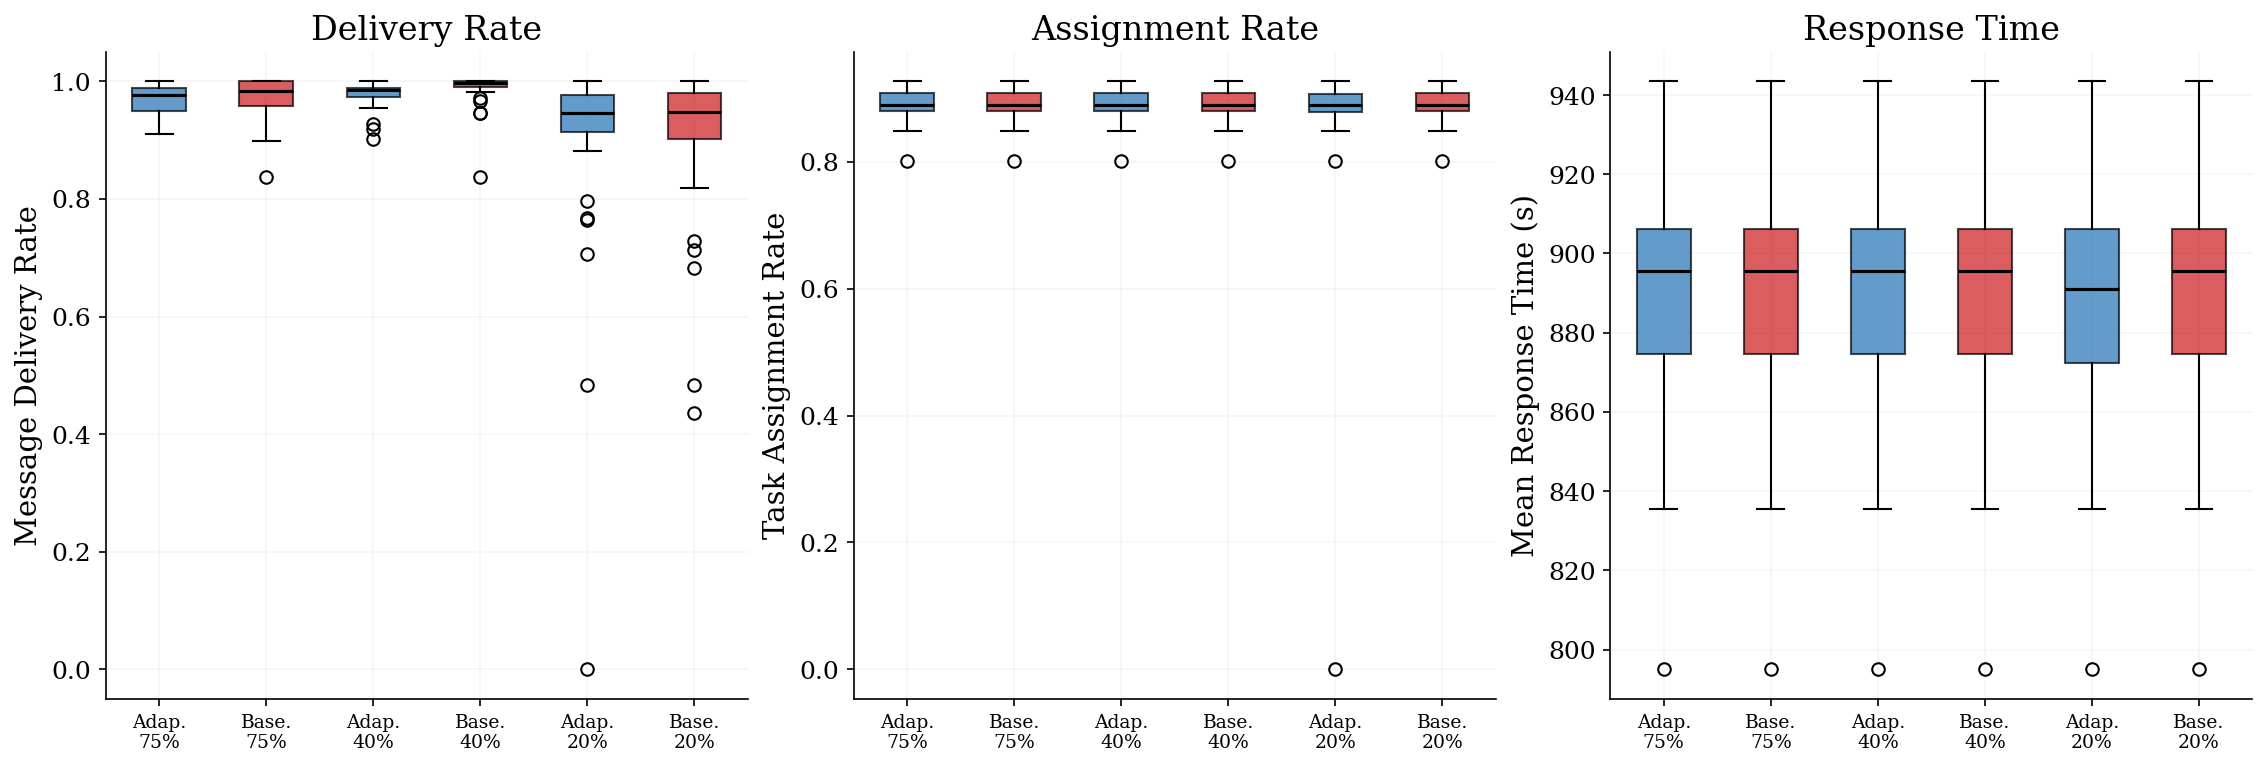

In [10]:
# Figure 4: Box Plot Distributions
fig = plot_box_distributions(df)
save_figure(fig, "fig_box_distributions", FIGURES_DIR)
plt.show()

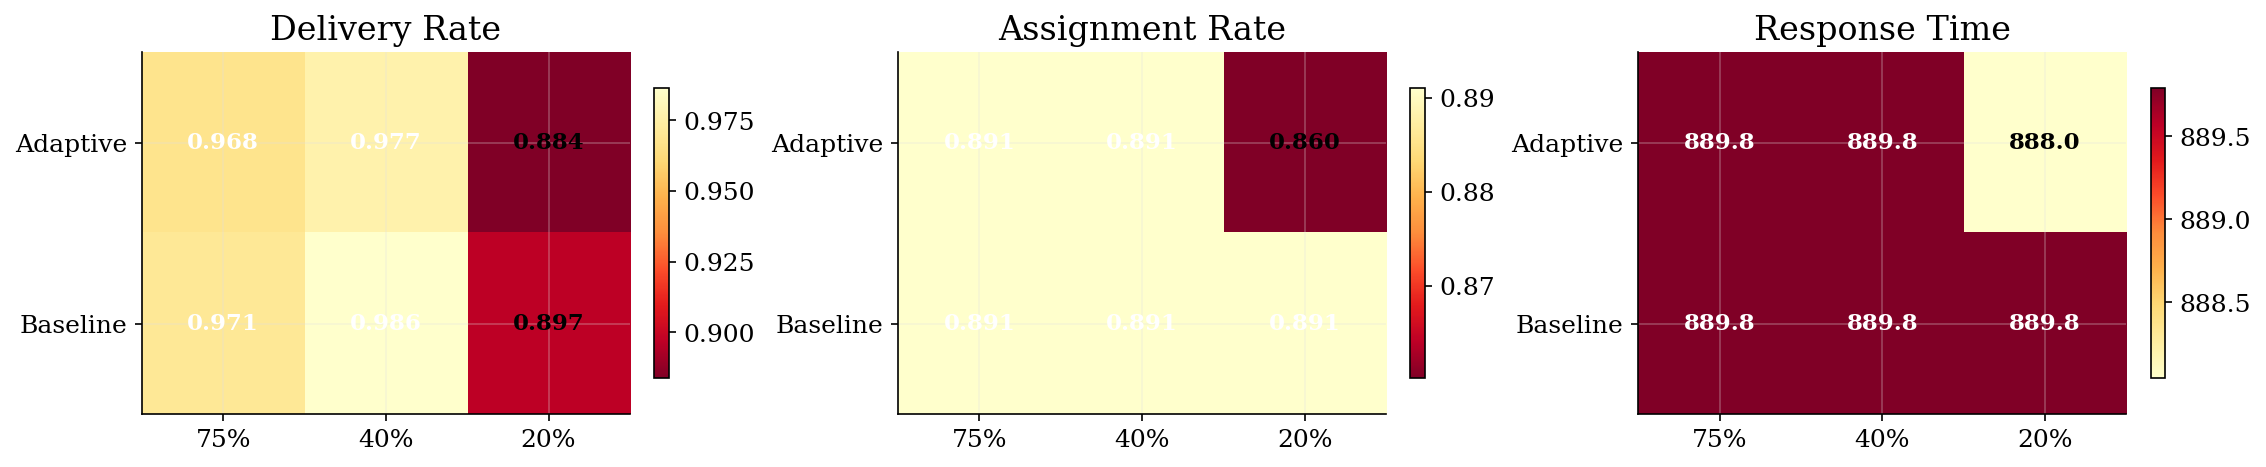

In [11]:
# Figure 5: Performance Heatmap
fig = plot_heatmap(df)
save_figure(fig, "fig_heatmap", FIGURES_DIR)
plt.show()

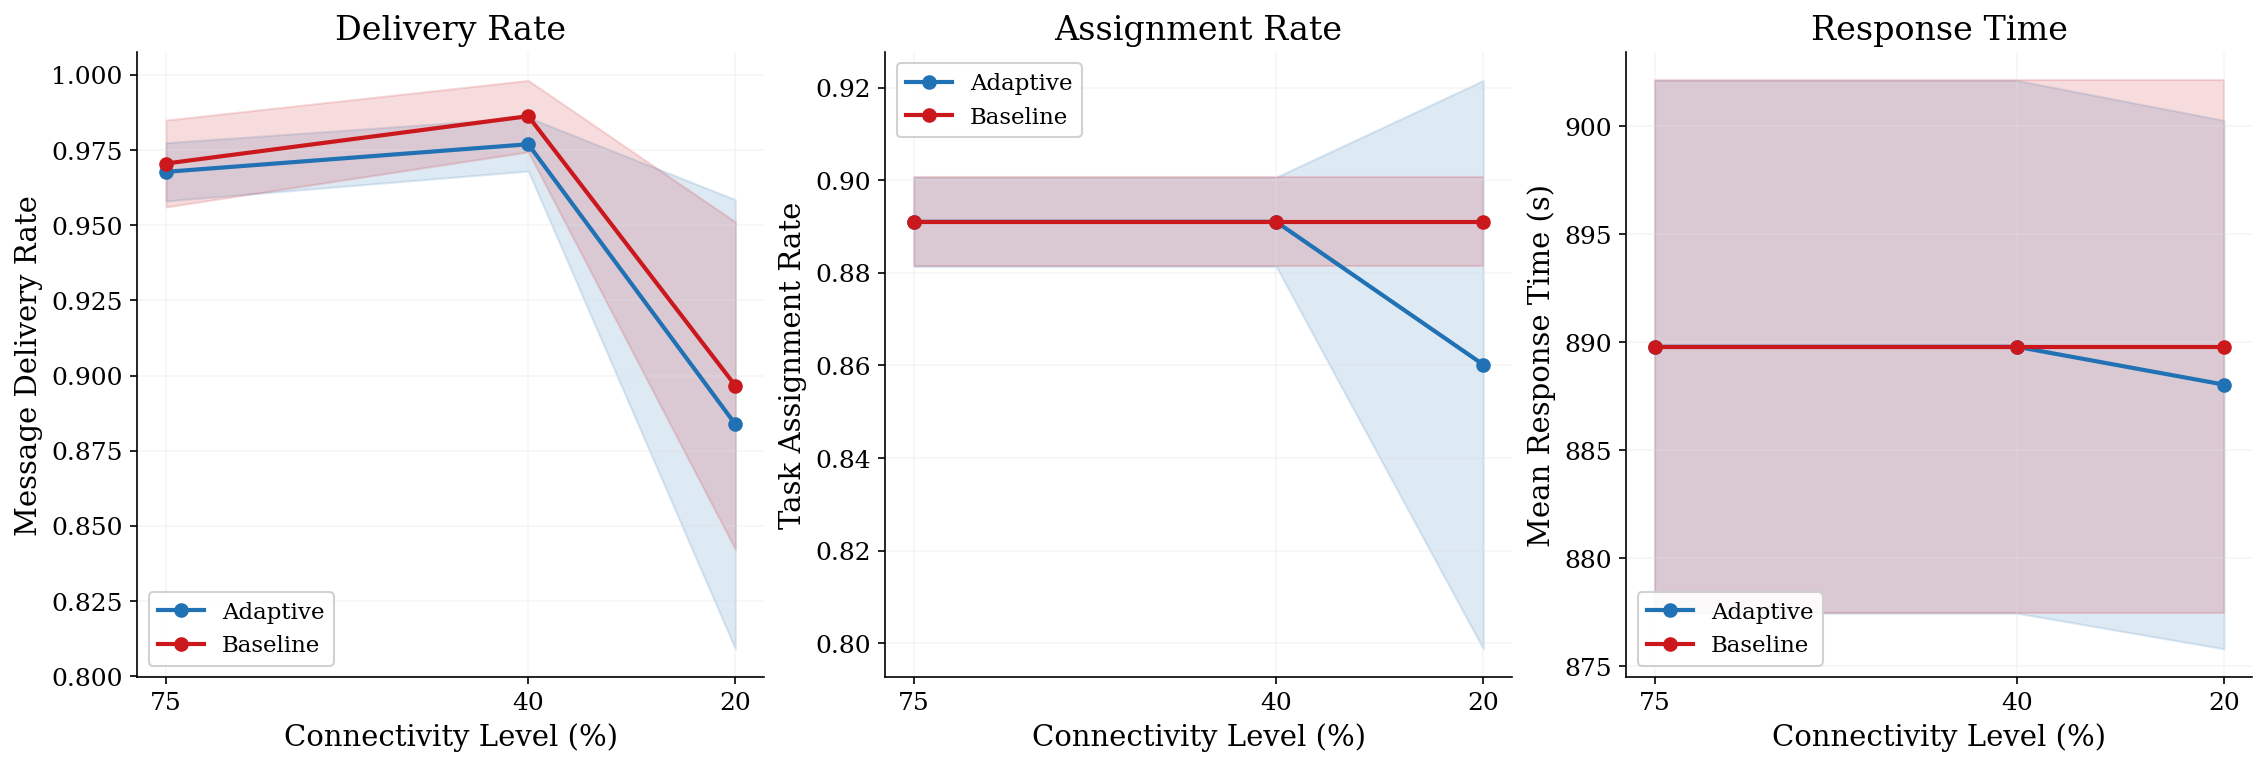

In [12]:
# Figure 6: Connectivity Degradation Lines
fig = plot_degradation_lines(summaries)
save_figure(fig, "fig_degradation_lines", FIGURES_DIR)
plt.show()

In [13]:
# Summary of saved figures
figure_files = sorted(FIGURES_DIR.glob("fig_*.png"))
print(f"\nGenerated {len(figure_files)} figures in {FIGURES_DIR}:")
for f in figure_files:
    print(f"  {f.name}")


Generated 16 figures in /Users/dianafonseca/resilient-emergency-response/outputs/figures:
  fig_assignment_rate_bars.png
  fig_box_distributions.png
  fig_degradation_lines.png
  fig_delivery_rate_bars.png
  fig_heatmap.png
  fig_journey_adaptive.png
  fig_journey_baseline.png
  fig_paths_adaptive.png
  fig_paths_baseline.png
  fig_pred_evolution_adaptive.png
  fig_pred_evolution_baseline.png
  fig_pred_heatmap_adaptive.png
  fig_pred_heatmap_baseline.png
  fig_predictability_adaptive.png
  fig_predictability_baseline.png
  fig_response_time_bars.png


## 3b. Network Diagnostics

Visualizations of the PRoPHET routing protocol, message forwarding,
and node mobility — generated from a single representative simulation
at 20% connectivity (the most challenging scenario for the research question).

In [14]:
from ercs.visualization.animation import run_paired_simulation
from ercs.visualization.diagnostics import (
    find_message_journeys,
    plot_all_message_paths,
    plot_message_journey,
    plot_predictability_evolution,
    plot_predictability_graph,
    plot_predictability_heatmap,
)

DIAG_CONNECTIVITY = 0.20  # Most interesting for research question
DIAG_SEED = 42
SAMPLE_INTERVAL = 30.0

print(f"Running paired simulation at {DIAG_CONNECTIVITY:.0%} connectivity...")
t0 = time.time()

adaptive_frames, baseline_frames, adaptive_fwd, baseline_fwd = run_paired_simulation(
    config=config,
    connectivity_level=DIAG_CONNECTIVITY,
    seed=DIAG_SEED,
    sample_interval=SAMPLE_INTERVAL,
)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s — {len(adaptive_frames)} frames captured per algorithm")

Running paired simulation at 20% connectivity...
Done in 24.1s — 200 frames captured per algorithm


Predictability graph at t=3001s



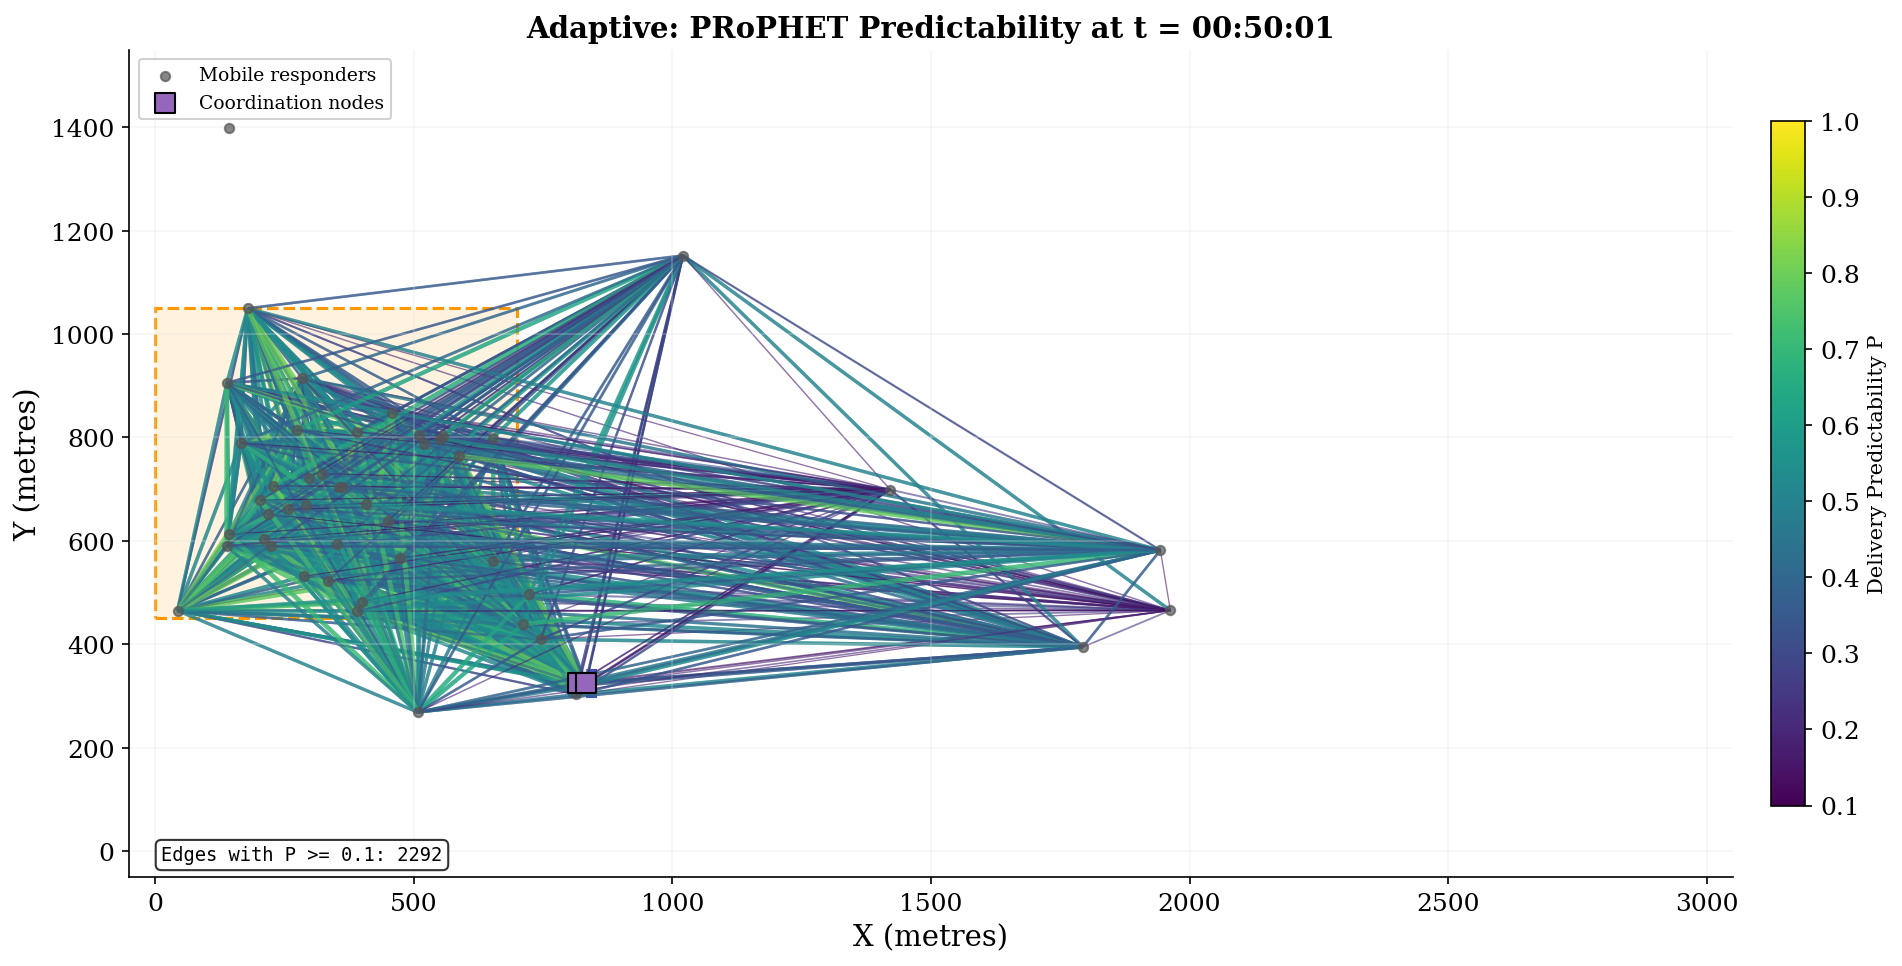

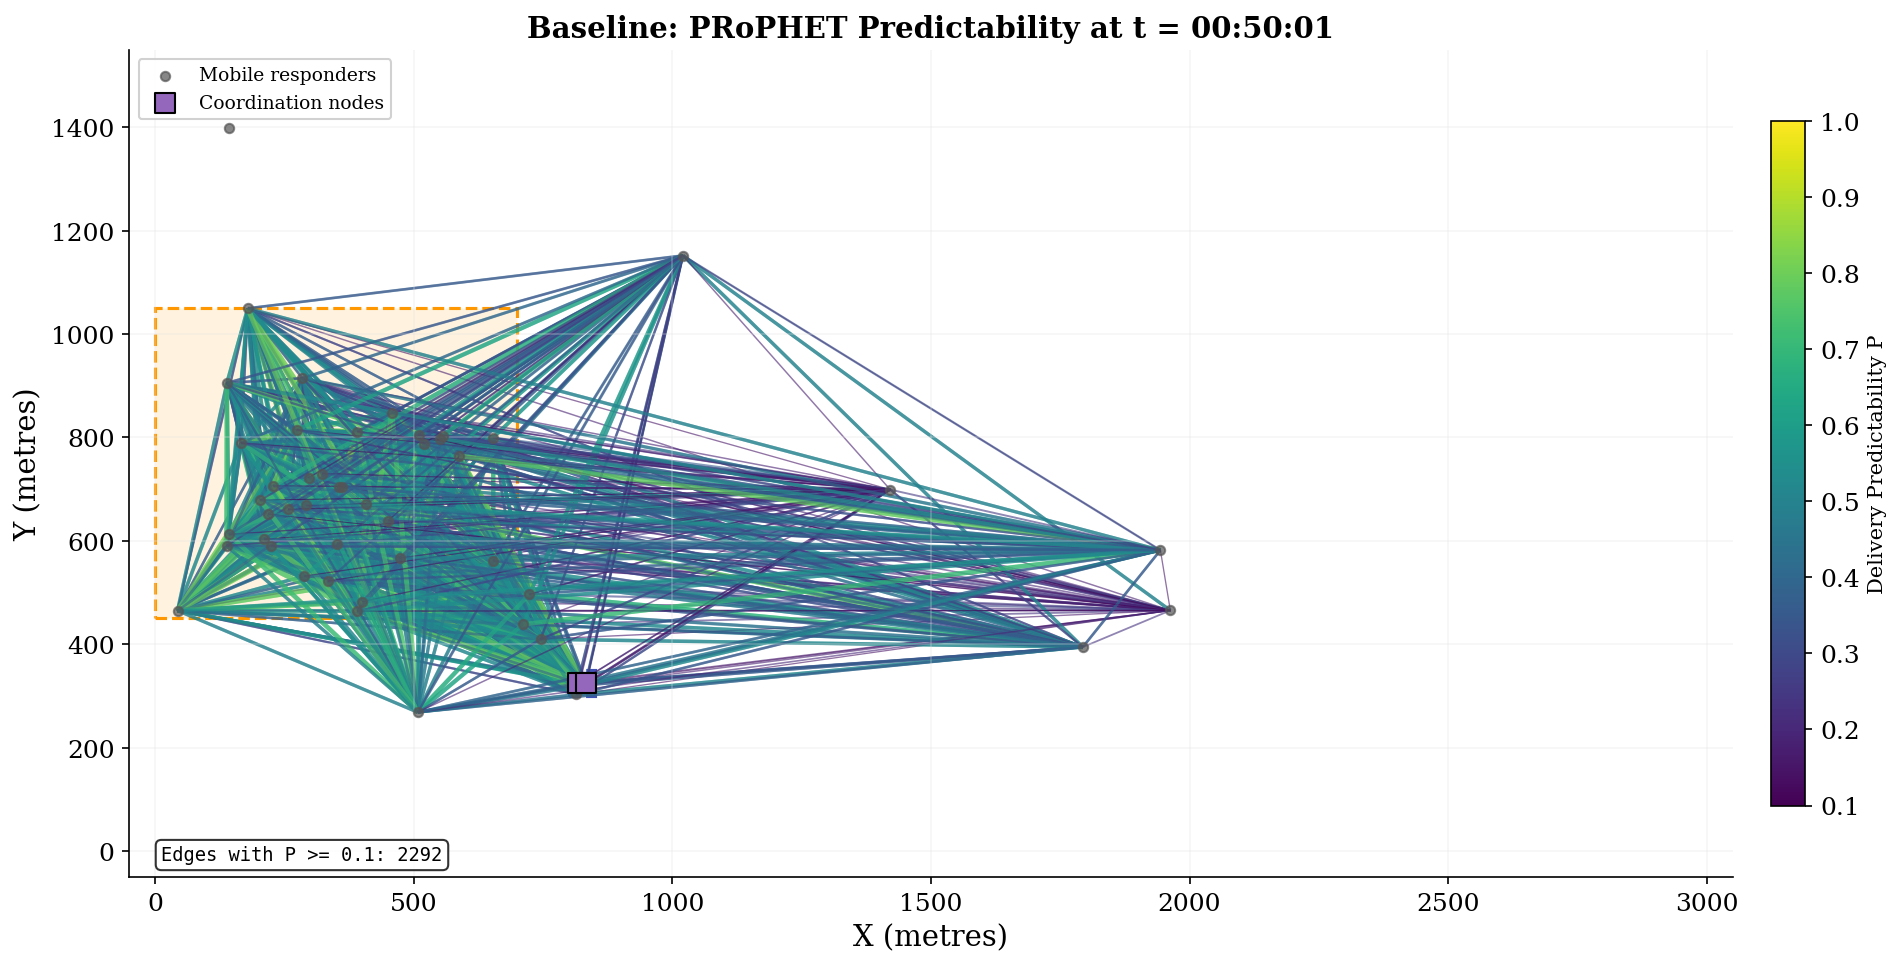

In [15]:
# Figure 7: PRoPHET Predictability Network at simulation midpoint
mid = len(adaptive_frames) // 2
print(f"Predictability graph at t={adaptive_frames[mid].timestamp:.0f}s\n")

for label, frames in [("Adaptive", adaptive_frames), ("Baseline", baseline_frames)]:
    fig = plot_predictability_graph(frames[mid], config, algorithm_label=label)
    save_figure(fig, f"fig_predictability_{label.lower()}", FIGURES_DIR)
    plt.show()

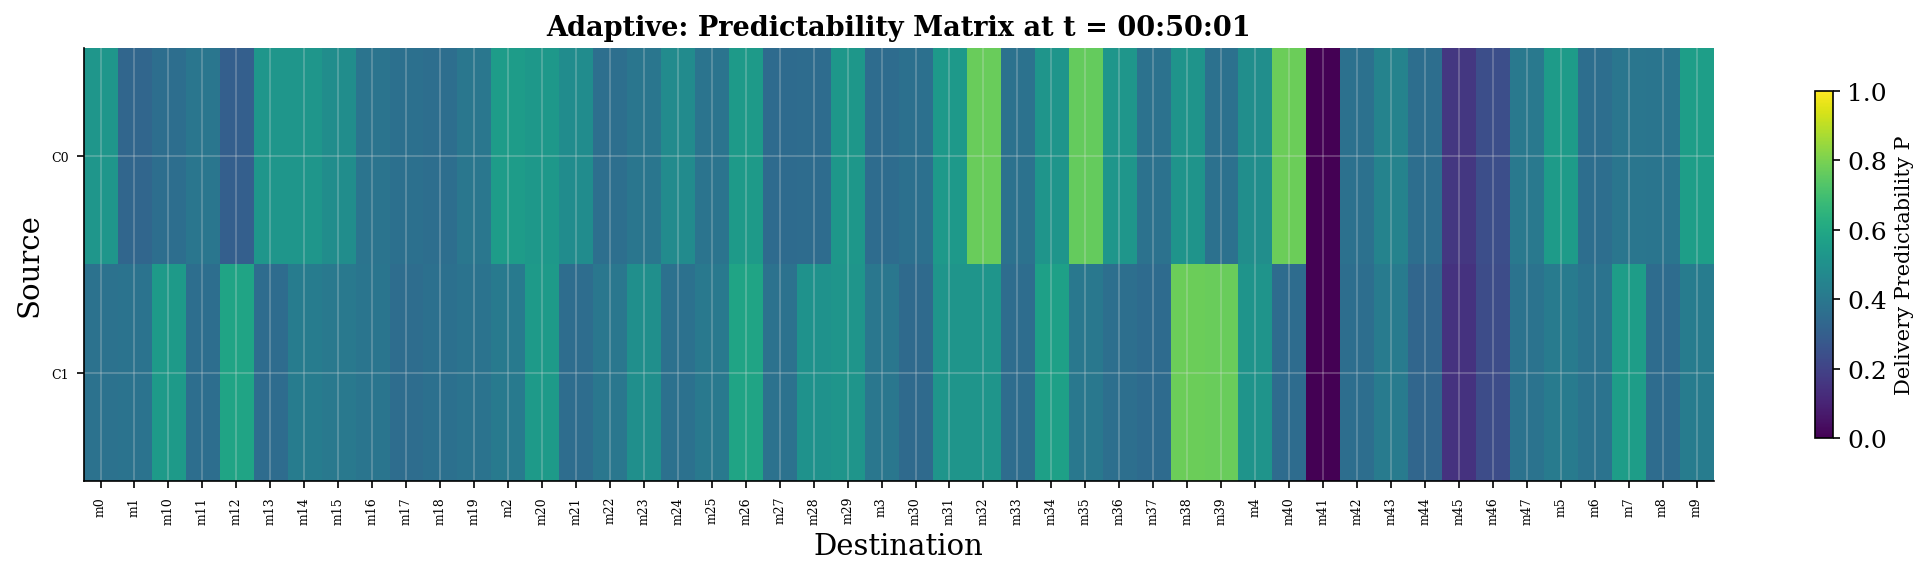

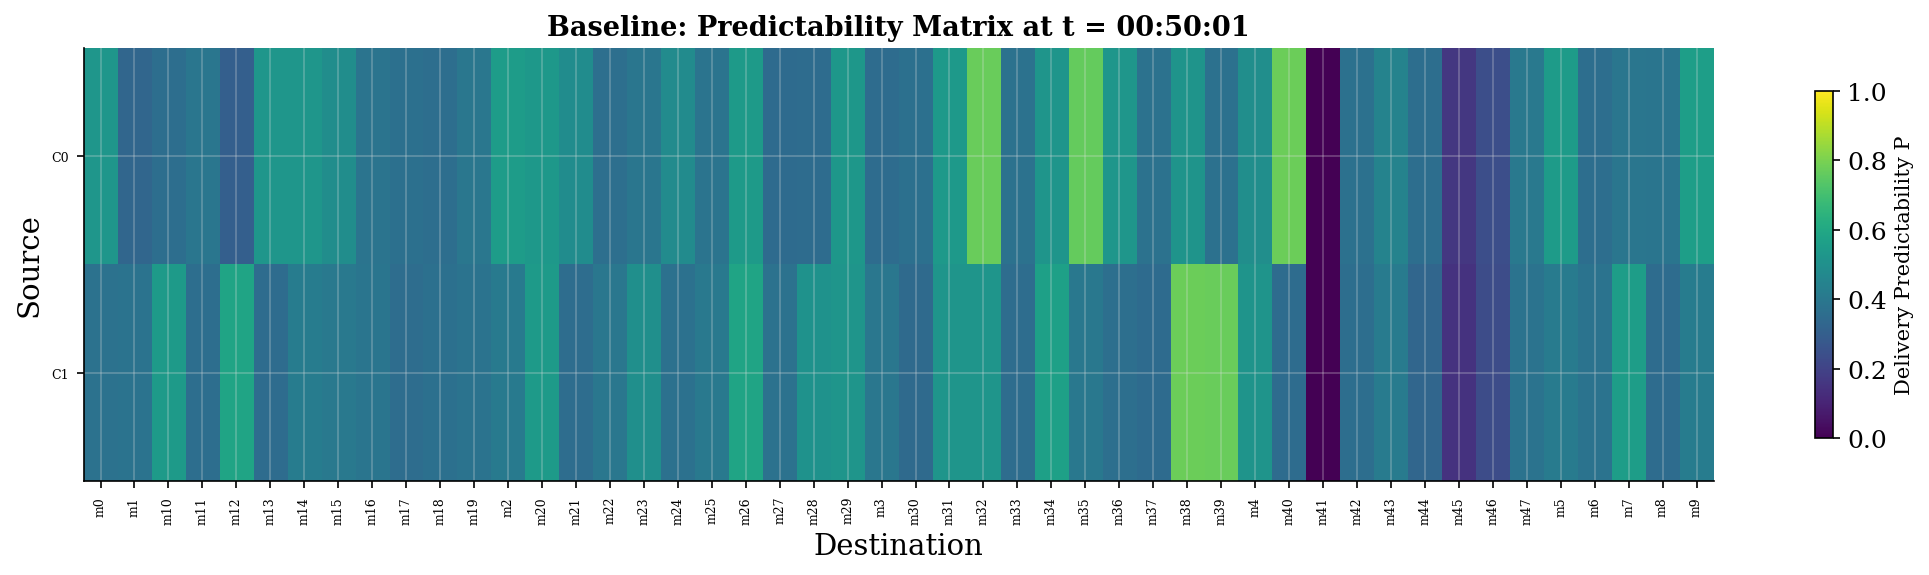

In [16]:
# Figure 8: Predictability Heatmap (Coord → Mobile)
for label, frames in [("Adaptive", adaptive_frames), ("Baseline", baseline_frames)]:
    fig = plot_predictability_heatmap(frames[mid], algorithm_label=label)
    save_figure(fig, f"fig_pred_heatmap_{label.lower()}", FIGURES_DIR)
    plt.show()

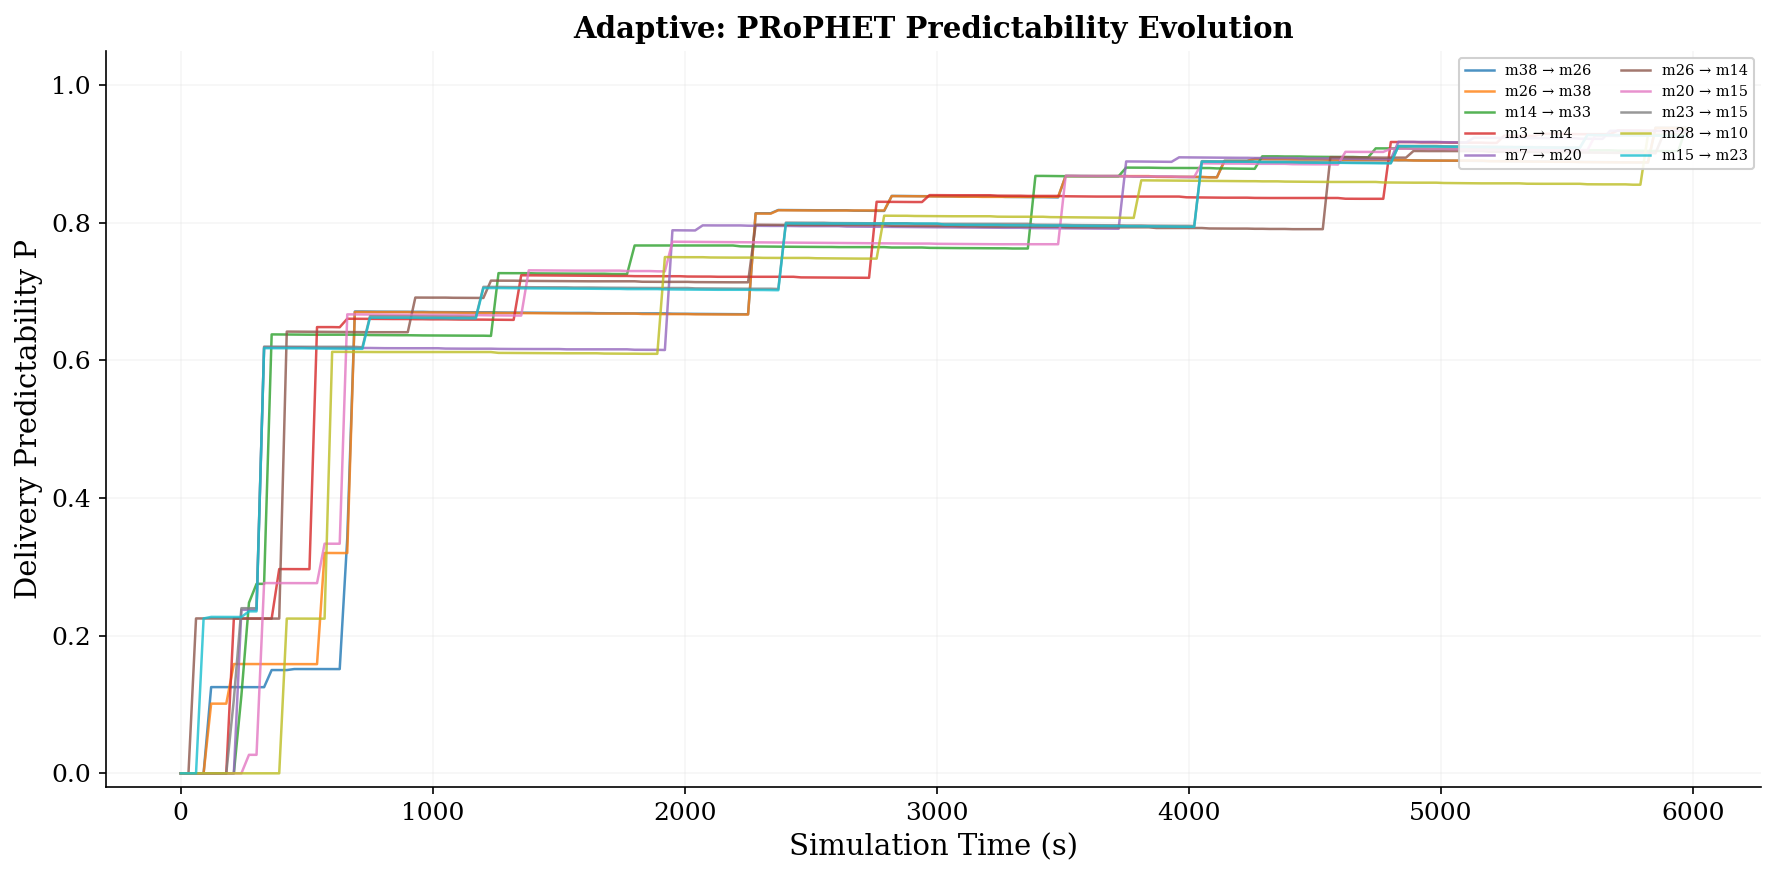

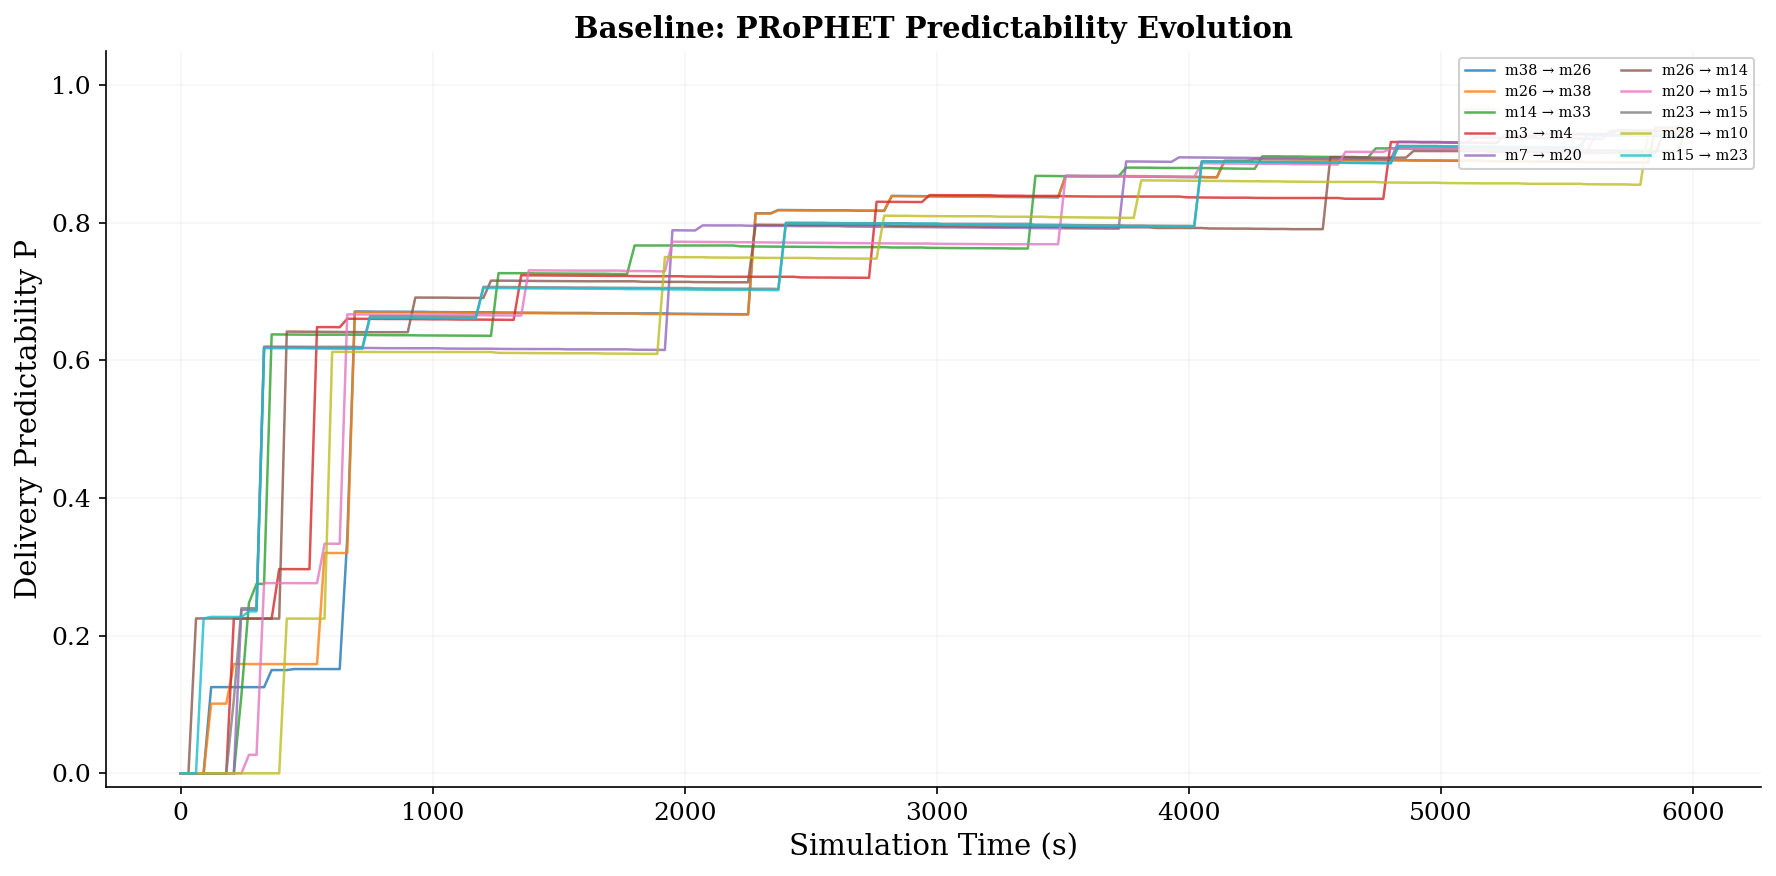

In [17]:
# Figure 9: Predictability Evolution Over Time
for label, frames in [("Adaptive", adaptive_frames), ("Baseline", baseline_frames)]:
    fig = plot_predictability_evolution(frames, algorithm_label=label)
    save_figure(fig, f"fig_pred_evolution_{label.lower()}", FIGURES_DIR)
    plt.show()

Adaptive: tracking message 6b6fd33c-b312-4e... (1 hops)


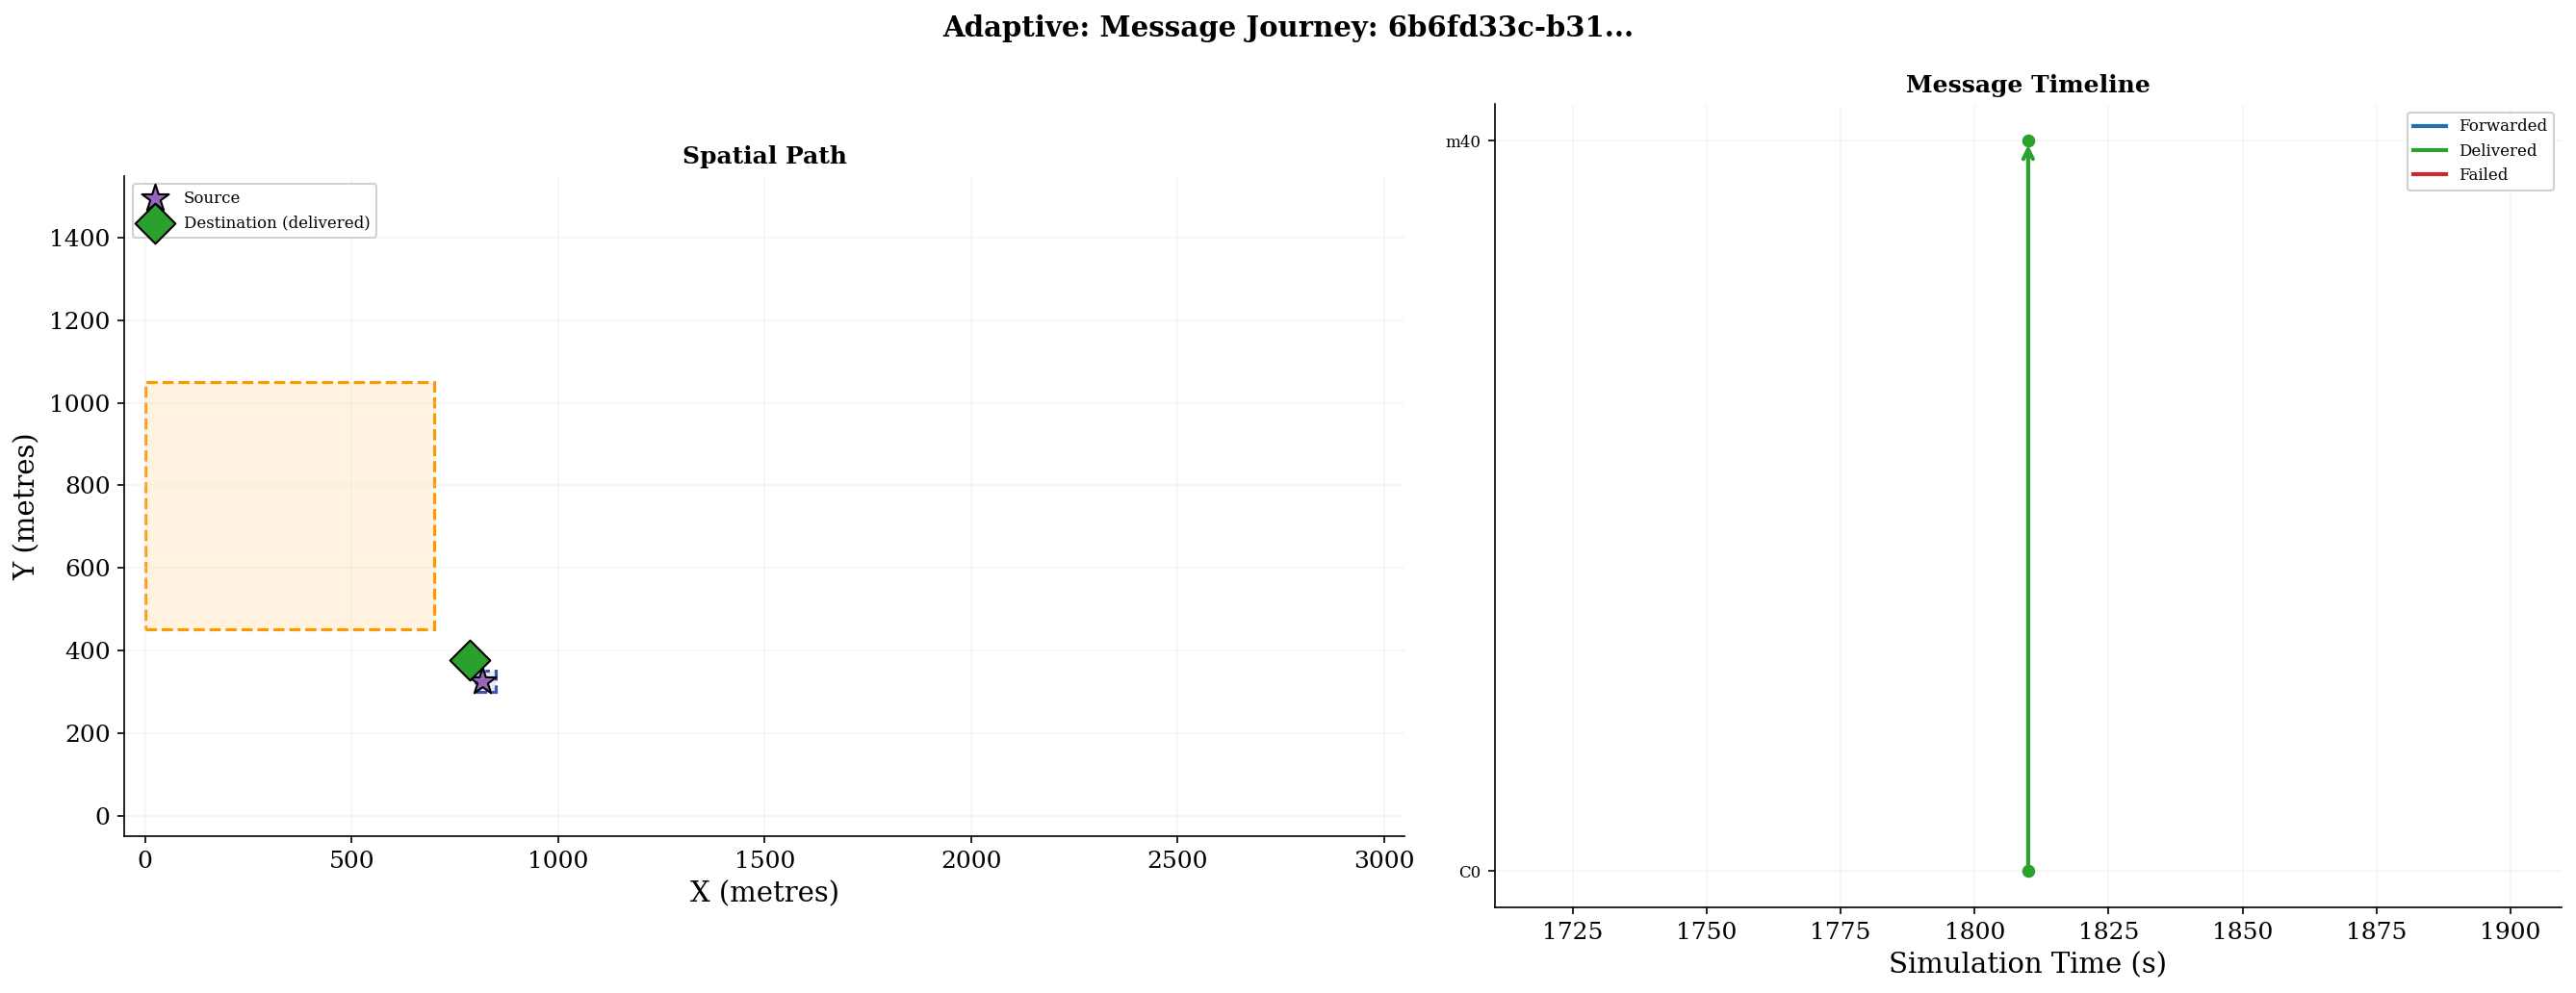

Baseline: tracking message bd98423e-7f7b-46... (273 hops)


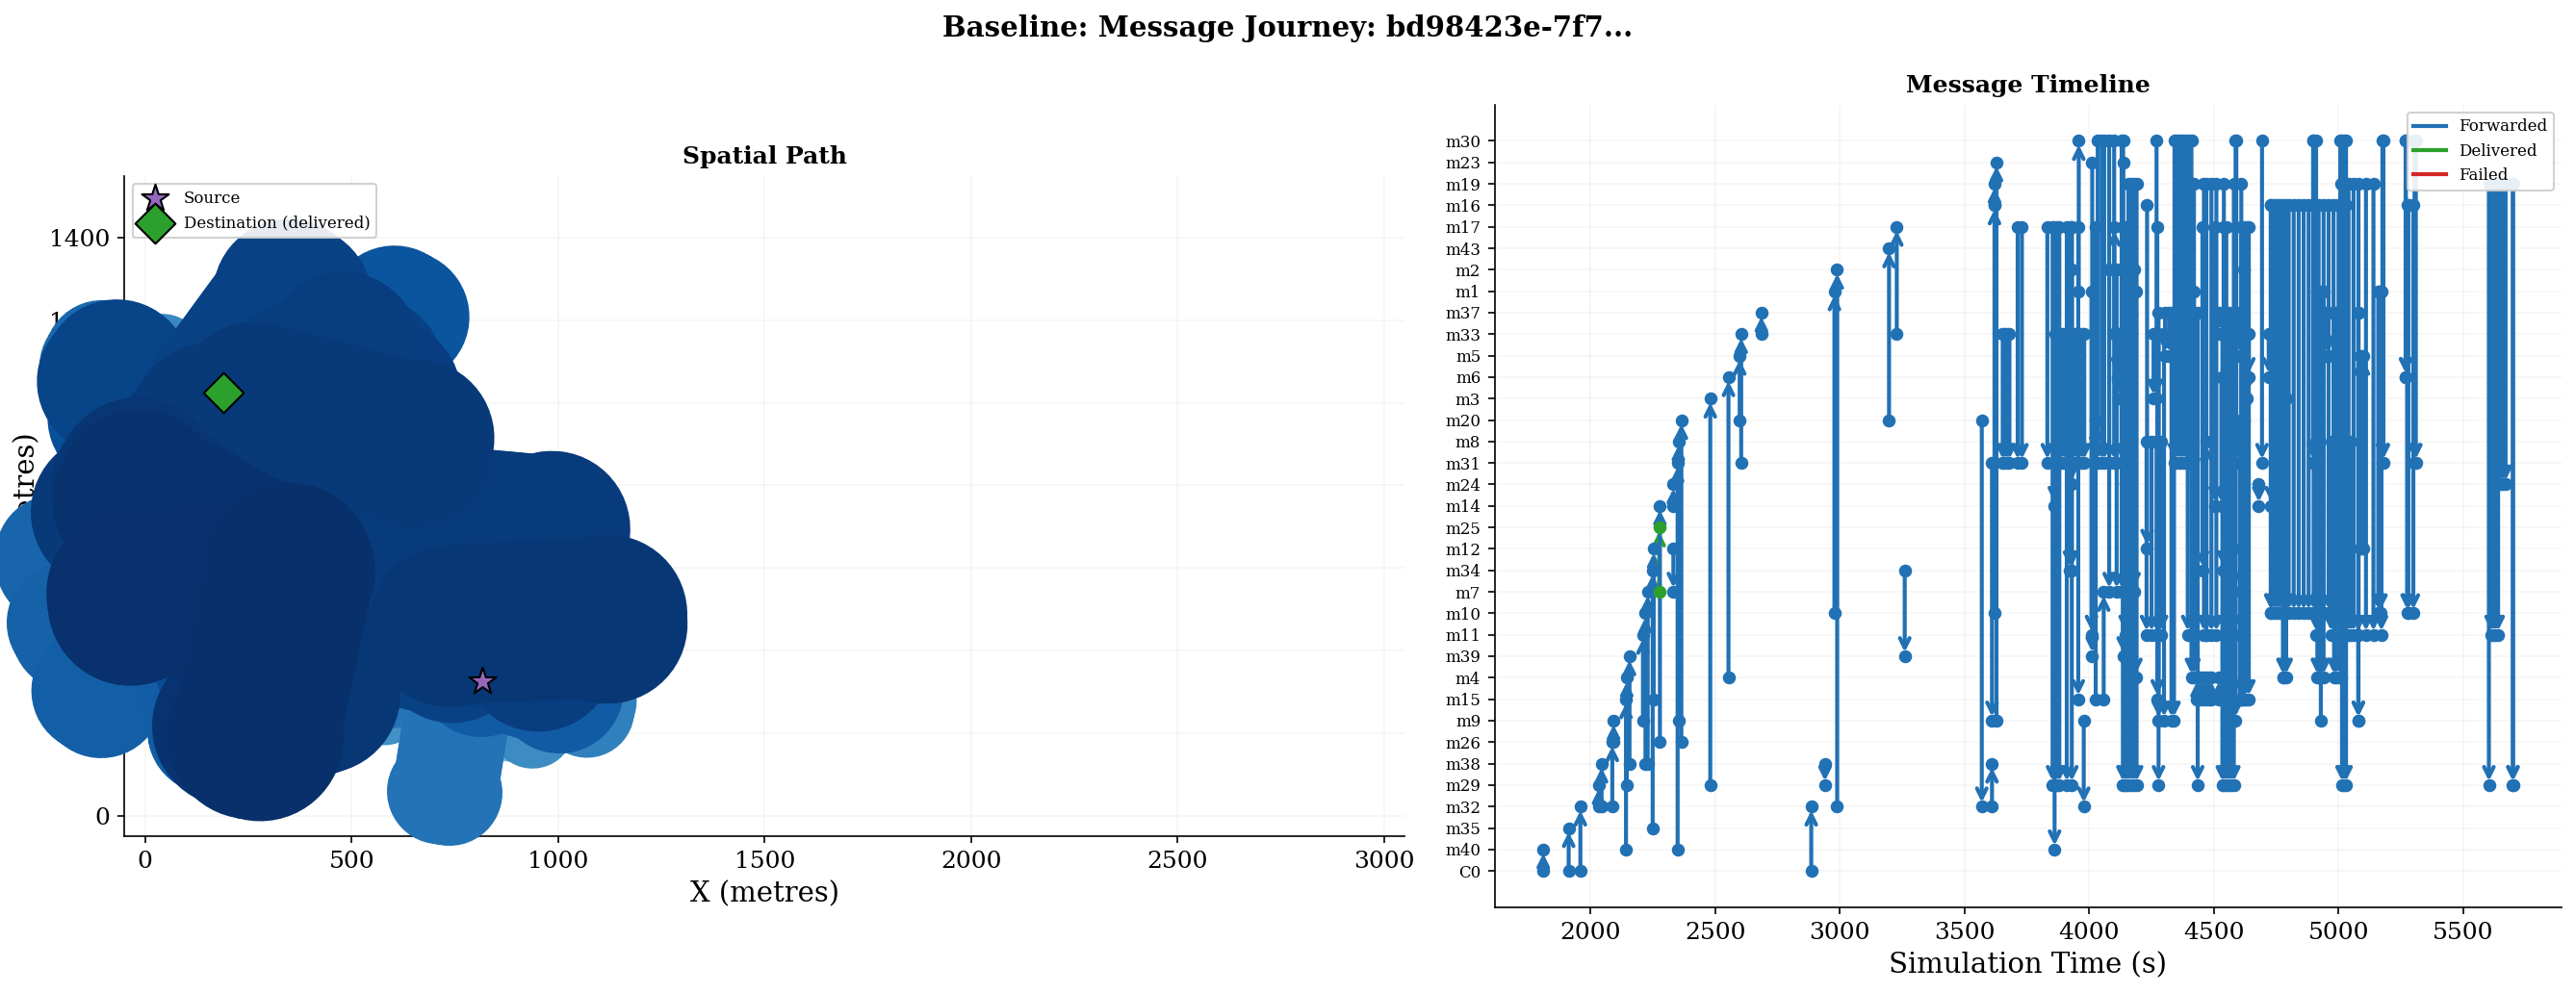

In [18]:
# Figure 10: Message Journey (first forwarded message per algorithm)
for label, fwd_log, frames in [
    ("Adaptive", adaptive_fwd, adaptive_frames),
    ("Baseline", baseline_fwd, baseline_frames),
]:
    journeys = find_message_journeys(fwd_log)
    if not journeys:
        print(f"  {label}: no messages forwarded")
        continue

    msg_id = min(journeys.keys(), key=lambda m: journeys[m][0].timestamp)
    print(f"{label}: tracking message {msg_id[:16]}... ({len(journeys[msg_id])} hops)")

    fig = plot_message_journey(msg_id, journeys[msg_id], frames, config, algorithm_label=label)
    save_figure(fig, f"fig_journey_{label.lower()}", FIGURES_DIR)
    plt.show()

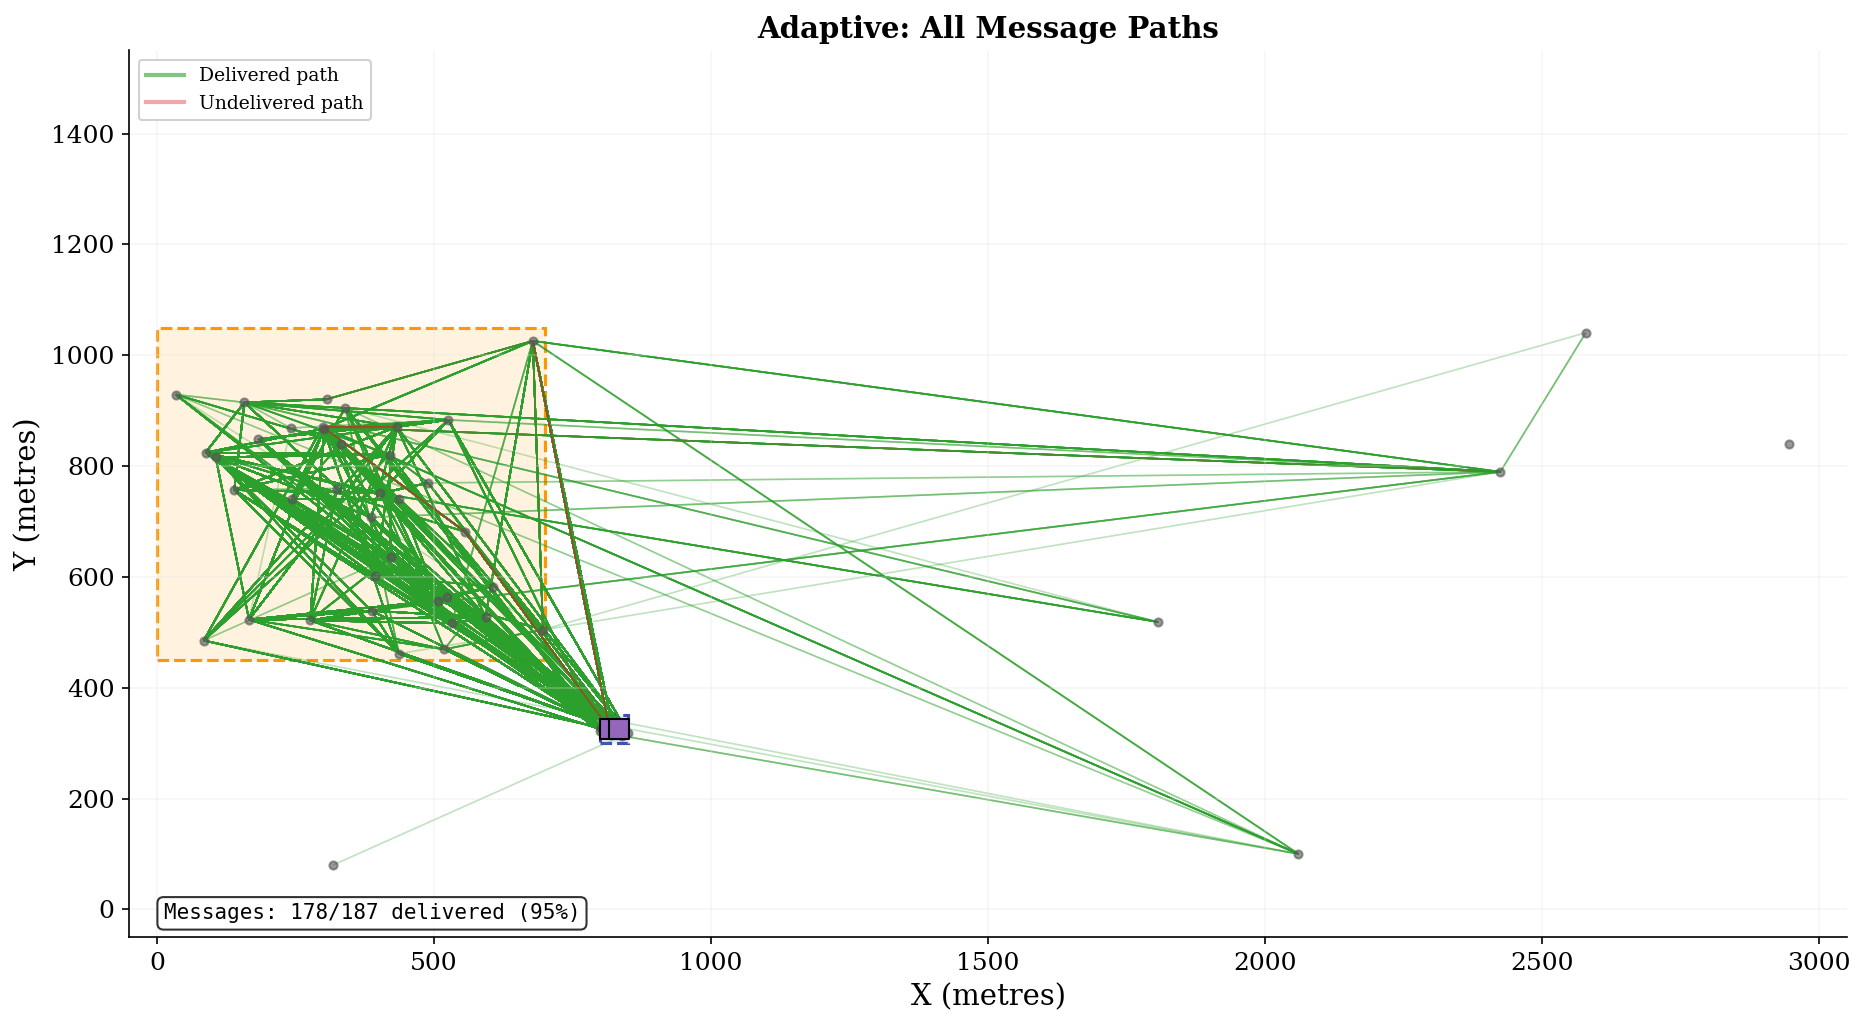

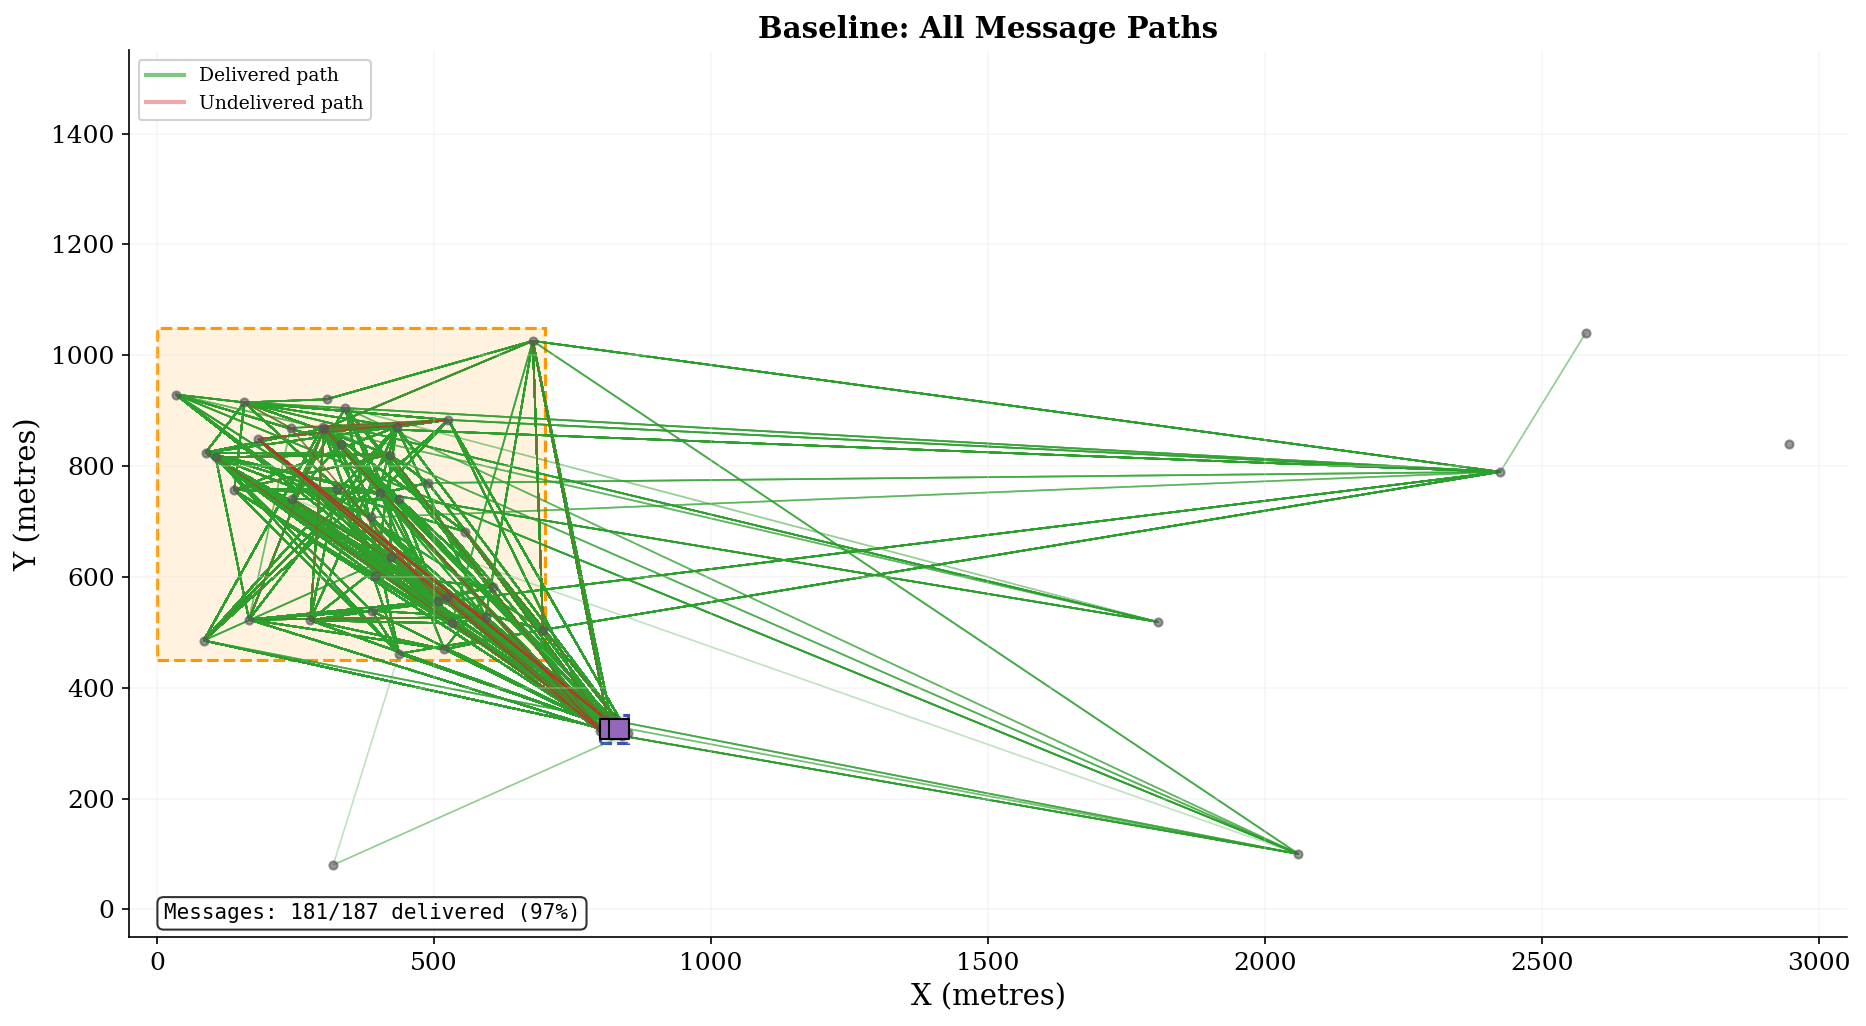


Total figures saved: 16 in /Users/dianafonseca/resilient-emergency-response/outputs/figures
  fig_assignment_rate_bars.png
  fig_box_distributions.png
  fig_degradation_lines.png
  fig_delivery_rate_bars.png
  fig_heatmap.png
  fig_journey_adaptive.png
  fig_journey_baseline.png
  fig_paths_adaptive.png
  fig_paths_baseline.png
  fig_pred_evolution_adaptive.png
  fig_pred_evolution_baseline.png
  fig_pred_heatmap_adaptive.png
  fig_pred_heatmap_baseline.png
  fig_predictability_adaptive.png
  fig_predictability_baseline.png
  fig_response_time_bars.png


In [19]:
# Figure 11: All Message Paths Overview
for label, frames, fwd_log in [
    ("Adaptive", adaptive_frames, adaptive_fwd),
    ("Baseline", baseline_frames, baseline_fwd),
]:
    fig = plot_all_message_paths(frames, fwd_log, config, algorithm_label=label)
    save_figure(fig, f"fig_paths_{label.lower()}", FIGURES_DIR)
    plt.show()

# Updated figure count
figure_files = sorted(FIGURES_DIR.glob("fig_*.png"))
print(f"\nTotal figures saved: {len(figure_files)} in {FIGURES_DIR}")
for f in figure_files:
    print(f"  {f.name}")

## 4. Statistical Analysis

Comparing algorithms using Welch's t-test (per connectivity level) and
one-way ANOVA (across connectivity levels). Significance level: \u03b1 = 0.05.

In [20]:
evaluator = PerformanceEvaluator(results)
report = evaluator.generate_report(
    metrics=[MetricType.DELIVERY_RATE, MetricType.ASSIGNMENT_RATE, MetricType.RESPONSE_TIME]
)

In [21]:
# Table 1: Welch's t-test Results
ttest_df = build_ttest_table(report)
display(
    ttest_df.style
    .set_caption("Table 1: Welch's t-test Results (Adaptive vs Baseline)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Connectivity,Adaptive (mean ± std),Baseline (mean ± std),Improvement,t,p-value,Cohen's d,Sig.
Delivery Rate,Overall,0.9428 ± 0.1234,0.9512 ± 0.0964,-0.87%,-0.504,0.6148,-0.075,No
Delivery Rate,20%,0.8838 ± 0.2001,0.8967 ± 0.1458,-1.43%,-0.284,0.7773,-0.073,No
Delivery Rate,40%,0.9769 ± 0.0239,0.9863 ± 0.0318,-0.95%,-1.288,0.2033,-0.333,No
Delivery Rate,75%,0.9678 ± 0.0260,0.9705 ± 0.0387,-0.28%,-0.325,0.7467,-0.084,No
Assignment Rate,Overall,0.8807 ± 0.0972,0.8910 ± 0.0255,-1.15%,-0.970,0.3341,-0.145,No
Assignment Rate,20%,0.8602 ± 0.1644,0.8910 ± 0.0258,-3.46%,-1.015,0.3179,-0.262,No
Assignment Rate,40%,0.8910 ± 0.0258,0.8910 ± 0.0258,+0.00%,0.000,1.0000,0.000,No
Assignment Rate,75%,0.8910 ± 0.0258,0.8910 ± 0.0258,+0.00%,0.000,1.0000,0.000,No
Response Time,Overall,889.2208 ± 32.3747,889.7913 ± 32.6440,-0.06%,-0.117,0.9067,-0.018,No
Response Time,20%,888.0405 ± 32.1531,889.7913 ± 33.0171,-0.20%,-0.206,0.8373,-0.054,No


In [22]:
# Table 2: ANOVA Results
anova_df = build_anova_table(report)
display(
    anova_df.style
    .set_caption("Table 2: One-way ANOVA Results (Effect of Connectivity)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Algorithm,F,p-value,df,η²,Effect,Sig.
Delivery Rate,Adaptive,5.745,0.0045,"(2, 87)",0.117,medium,Yes
Delivery Rate,Baseline,8.668,0.0004,"(2, 87)",0.166,large,Yes
Assignment Rate,Adaptive,1.007,0.3696,"(2, 87)",0.023,small,No
Assignment Rate,Baseline,0.000,1.0000,"(2, 87)",0.000,negligible,No
Response Time,Adaptive,0.028,0.9724,"(2, 86)",0.001,negligible,No
Response Time,Baseline,0.000,1.0000,"(2, 87)",0.000,negligible,No


In [23]:
# Effect Size Interpretation
print("Effect Size Interpretation")
print("=" * 65)
for comp in report.comparisons:
    d = abs(comp.ttest.cohens_d)
    if d < 0.2:
        size = "negligible"
    elif d < 0.5:
        size = "small"
    elif d < 0.8:
        size = "medium"
    else:
        size = "large"
    if comp.connectivity_level is not None:
        label = f"{comp.metric.value} @ {comp.connectivity_level * 100:.0f}%"
    else:
        label = f"{comp.metric.value} (overall)"
    sig = "*" if comp.ttest.significant else ""
    print(f"  {label:40s}  d = {comp.ttest.cohens_d:+.3f} ({size}){sig}")

Effect Size Interpretation
  delivery_rate (overall)                   d = -0.075 (negligible)
  delivery_rate @ 20%                       d = -0.073 (negligible)
  delivery_rate @ 40%                       d = -0.333 (small)
  delivery_rate @ 75%                       d = -0.084 (negligible)
  assignment_rate (overall)                 d = -0.145 (negligible)
  assignment_rate @ 20%                     d = -0.262 (small)
  assignment_rate @ 40%                     d = +0.000 (negligible)
  assignment_rate @ 75%                     d = +0.000 (negligible)
  response_time (overall)                   d = -0.018 (negligible)
  response_time @ 20%                       d = -0.054 (negligible)
  response_time @ 40%                       d = +0.000 (negligible)
  response_time @ 75%                       d = +0.000 (negligible)


## 5. Key Findings

In [24]:
print("KEY FINDINGS")
print("=" * 60)

# 1. Overall delivery rate
overall_dr = next(
    (c for c in report.comparisons
     if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is None),
    None,
)
if overall_dr:
    print(f"\n1. DELIVERY RATE (Overall)")
    print(f"   Adaptive: {overall_dr.adaptive_stats.mean:.4f} +/- {overall_dr.adaptive_stats.std:.4f}")
    print(f"   Baseline: {overall_dr.baseline_stats.mean:.4f} +/- {overall_dr.baseline_stats.std:.4f}")
    print(f"   Improvement: {overall_dr.improvement:+.2f}%")
    print(f"   Significant: {'Yes' if overall_dr.ttest.significant else 'No'} (p={overall_dr.ttest.p_value:.4f})")

# 2. Where advantage is largest
per_conn = [
    c for c in report.comparisons
    if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is not None
]
if per_conn:
    best = max(per_conn, key=lambda c: c.improvement)
    print(f"\n2. LARGEST ADAPTIVE ADVANTAGE")
    print(f"   At {best.connectivity_level * 100:.0f}% connectivity: {best.improvement:+.2f}% improvement")

# 3. Connectivity effect
print(f"\n3. CONNECTIVITY EFFECT (ANOVA)")
for key, anova in report.anova_results.items():
    parts = key.rsplit("_", 1)
    metric_name = parts[0].replace("_", " ").title()
    algorithm = parts[1].capitalize() if len(parts) > 1 else "All"
    print(
        f"   {metric_name} ({algorithm}): "
        f"F({anova.df_between},{anova.df_within}) = {anova.f_statistic:.3f}, "
        f"p = {anova.p_value:.4f}, \u03b7\u00b2 = {anova.eta_squared:.3f}"
    )

print("\n" + "=" * 60)
print(f"Experiment complete. All figures saved to: {FIGURES_DIR}")

KEY FINDINGS

1. DELIVERY RATE (Overall)
   Adaptive: 0.9428 +/- 0.1234
   Baseline: 0.9512 +/- 0.0964
   Improvement: -0.87%
   Significant: No (p=0.6148)

2. LARGEST ADAPTIVE ADVANTAGE
   At 75% connectivity: -0.28% improvement

3. CONNECTIVITY EFFECT (ANOVA)
   Delivery Rate (Adaptive): F(2,87) = 5.745, p = 0.0045, η² = 0.117
   Delivery Rate (Baseline): F(2,87) = 8.668, p = 0.0004, η² = 0.166
   Assignment Rate (Adaptive): F(2,87) = 1.007, p = 0.3696, η² = 0.023
   Assignment Rate (Baseline): F(2,87) = 0.000, p = 1.0000, η² = 0.000
   Response Time (Adaptive): F(2,86) = 0.028, p = 0.9724, η² = 0.001
   Response Time (Baseline): F(2,87) = 0.000, p = 1.0000, η² = 0.000

Experiment complete. All figures saved to: /Users/dianafonseca/resilient-emergency-response/outputs/figures
